# Pipeline de lectura de placas: RF-DETR + TrOCR

Une los dos modelos entrenados en este proyecto:

1. **Lectura** de las imágenes de `data/vehicles`.
2. **Normalización y resize** para el detector (576×576, media/desviación de ImageNet).
3. **Detección de placas** con RF-DETR (`outputs/rf_detr_license_plates/final`).
4. **Recorte** de cada placa detectada.
5. **Normalización y resize** para el OCR (384×384, media/desviación 0.5).
6. **OCR** de cada recorte con TrOCR (`outputs/final`).
7. **Imagen de salida** con las cajas y el texto leído, guardada en `outputs/pipeline`.

Selecciona el kernel **Python (RF-DETR)**: ejecuta ambos modelos con Transformers 5.

> El modelo OCR de `outputs/final` se ajustó con IAM (texto manuscrito en inglés), no con placas. Lee placas nítidas y
> cercanas, pero confundirá caracteres en placas pequeñas o borrosas. Para mejorarlo hay que ajustar TrOCR con recortes
> de placas y su texto.

## Configuración

Rutas de los modelos, de las imágenes y de la salida, y los parámetros del pipeline. `DET_THRESHOLD` es la confianza
mínima para aceptar una placa; `CROP_PADDING` amplía cada caja (en fracción de su ancho y alto) para no cortar
caracteres de los bordes. Las placas con menos de `MIN_OCR_WIDTH` píxeles de ancho se dibujan, pero no se leen: a esa
resolución el OCR solo devuelve ruido.

In [1]:
import os
from pathlib import Path

import torch

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
DETECTOR_DIR = Path(os.environ.get("DETR_OUTPUT_DIR", project_dir / "outputs" / "rf_detr_license_plates")) / "final"
OCR_DIR = Path(os.environ.get("TROCR_OUTPUT_DIR", project_dir / "outputs")) / "final"
IMAGES_DIR = Path(os.environ.get("VEHICLES_DIR", project_dir / "data" / "vehicles"))
RESULTS_DIR = Path(os.environ.get("PIPELINE_OUTPUT_DIR", project_dir / "outputs" / "pipeline"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DET_THRESHOLD = 0.4
CROP_PADDING = (0.08, 0.15)  # (horizontal, vertical)
MIN_OCR_WIDTH = 60
BATCH_SIZE = 8

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Detector:", DETECTOR_DIR)
print("OCR:", OCR_DIR)
print("Imágenes:", IMAGES_DIR)
print("Resultados:", RESULTS_DIR)
print("Dispositivo:", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")

Detector: /home/mambauser/workspace/outputs/rf_detr_license_plates/final
OCR: /home/mambauser/workspace/outputs/final
Imágenes: /home/mambauser/workspace/data/vehicles
Resultados: /home/mambauser/workspace/outputs/pipeline
Dispositivo: NVIDIA GeForce RTX 5060 Ti


Una función auxiliar para mostrar varias imágenes en una cuadrícula:

In [2]:
import math

import matplotlib.pyplot as plt


def mostrar_galeria(imagenes, titulos=None, columnas=3, alto=4):
    filas = math.ceil(len(imagenes) / columnas)
    fig, axes = plt.subplots(filas, columnas, figsize=(columnas * alto * 1.4, filas * alto), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for i, (ax, imagen) in enumerate(zip(axes.flat, imagenes)):
        ax.imshow(imagen)
        if titulos:
            ax.set_title(titulos[i], fontsize=9)
    plt.tight_layout()
    plt.show()

## 1. Lectura de imágenes

Se leen todos los formatos habituales (JPEG, PNG, WebP…). `exif_transpose` aplica la rotación guardada en los metadatos
de las fotos de cámara o móvil, y `convert("RGB")` quita el canal alfa de los PNG y unifica imágenes en escala de grises.

cars.png                                                     700x412
gettyimages-1645361278-612x612.jpg                           612x408
heavy-traffic-la-six-lanes-footage-000759983_iconl.webp      480x268
highway_101_traffic.webp                                     1200x800
images (1).jpeg                                              638x481
images (2).jpeg                                              452x678
images.jpeg                                                  701x438
istockphoto-523091055-612x612.jpg                            612x408
traffic-166453_1280.jpg                                      853x1280


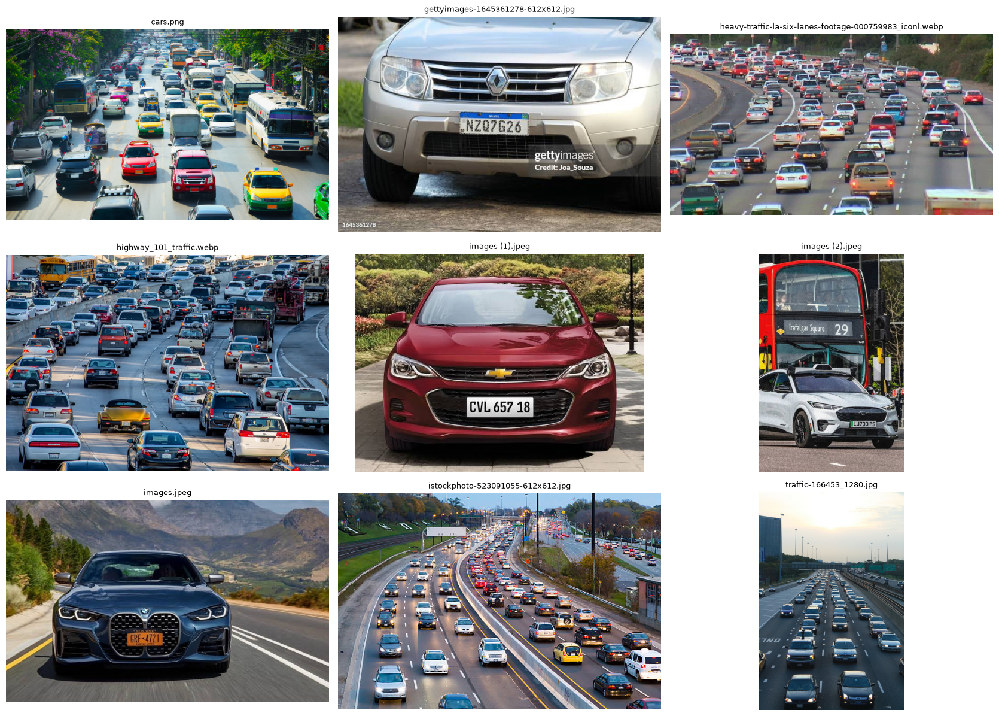

In [3]:
from PIL import Image, ImageOps

EXTENSIONES = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


def cargar_imagen(ruta):
    with Image.open(ruta) as imagen:
        return ImageOps.exif_transpose(imagen).convert("RGB")


rutas = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in EXTENSIONES)
if not rutas:
    raise FileNotFoundError(f"No hay imágenes en {IMAGES_DIR}")
imagenes = [cargar_imagen(ruta) for ruta in rutas]

for ruta, imagen in zip(rutas, imagenes):
    print(f"{ruta.name:<60} {imagen.width}x{imagen.height}")

mostrar_galeria(imagenes, [ruta.name for ruta in rutas])

## 2. Normalización y resize para el detector

El preprocesado debe ser idéntico al del entrenamiento, así que se usa el `image_processor` guardado junto al modelo:

* **Resize** a 576×576 (sin conservar la proporción; la imagen se estira).
* **Reescalado** de los píxeles de 0–255 a 0–1.
* **Normalización** por canal con la media y la desviación de ImageNet.

Como todas quedan en 576×576, las imágenes se procesan juntas en un único tensor.

In [4]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection

det_processor = AutoImageProcessor.from_pretrained(DETECTOR_DIR)
print("Tamaño:", det_processor.size)
print("Reescalado:", det_processor.rescale_factor)
print("Media:", det_processor.image_mean)
print("Desviación:", det_processor.image_std)

det_inputs = det_processor(images=imagenes, return_tensors="pt")
pixel_values = det_inputs["pixel_values"]
print("pixel_values:", tuple(pixel_values.shape))
print("Media por canal tras normalizar:", [f"{v:.3f}" for v in pixel_values.mean(dim=(0, 2, 3)).tolist()])
print("Desviación por canal tras normalizar:", [f"{v:.3f}" for v in pixel_values.std(dim=(0, 2, 3)).tolist()])

Tamaño: SizeDict(height=576, width=576, longest_edge=None, shortest_edge=None, max_height=None, max_width=None, min_pixels=None, max_pixels=None)
Reescalado: 0.00392156862745098
Media: (0.485, 0.456, 0.406)
Desviación: (0.229, 0.224, 0.225)
pixel_values: (9, 3, 576, 576)
Media por canal tras normalizar: ['-0.332', '-0.183', '0.069']
Desviación por canal tras normalizar: ['1.160', '1.136', '1.156']


Para ver lo que recibe el modelo, se deshace la normalización de cada tensor y se muestra como imagen:

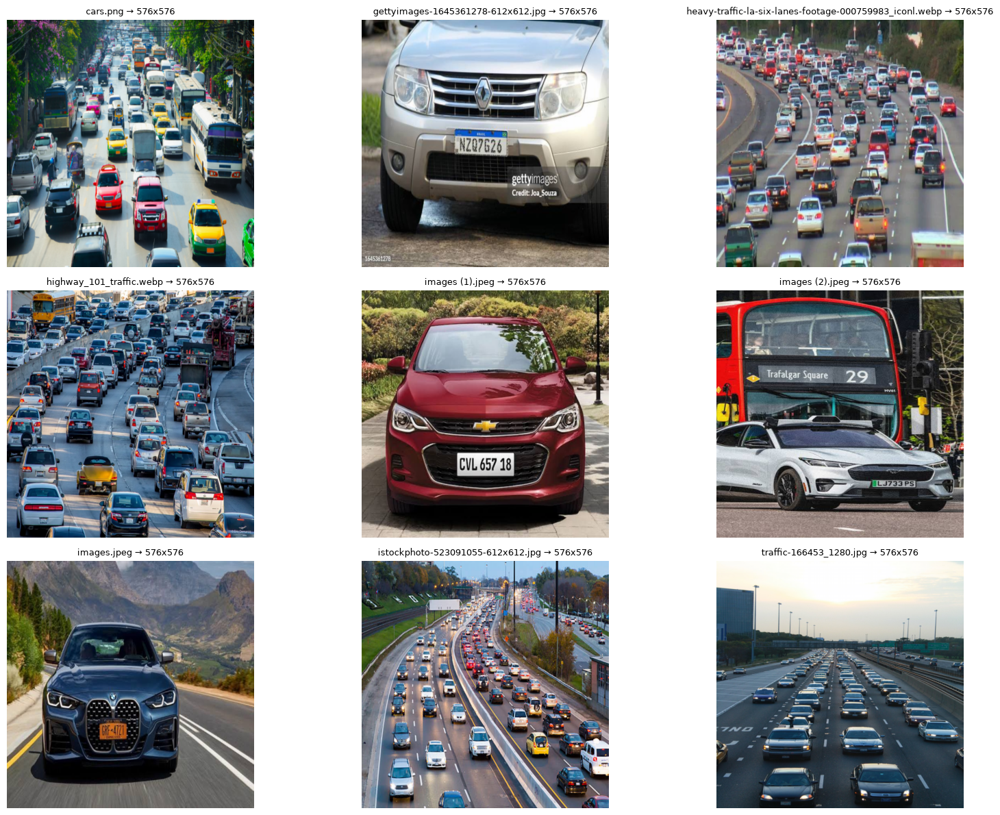

In [5]:
import numpy as np


def desnormalizar(tensor, media, desviacion):
    media = torch.tensor(media).view(3, 1, 1)
    desviacion = torch.tensor(desviacion).view(3, 1, 1)
    array = (tensor * desviacion + media).clamp(0, 1).permute(1, 2, 0).numpy()
    return (array * 255).astype(np.uint8)


mostrar_galeria(
    [desnormalizar(t, det_processor.image_mean, det_processor.image_std) for t in pixel_values],
    [f"{ruta.name} → 576x576" for ruta in rutas],
)

## 3. Detección de placas

RF-DETR predice cajas normalizadas sobre la imagen de 576×576. `post_process_object_detection` filtra por
`DET_THRESHOLD` y las convierte a píxeles de la imagen **original** gracias a `target_sizes`. Se procesa por lotes de
`BATCH_SIZE` para no agotar la memoria con carpetas grandes.

In [6]:
detector = AutoModelForObjectDetection.from_pretrained(DETECTOR_DIR).to(device)
detector.eval()


@torch.no_grad()
def detectar_placas(imagenes, threshold=DET_THRESHOLD):
    detecciones = []
    for inicio in range(0, len(imagenes), BATCH_SIZE):
        lote = imagenes[inicio:inicio + BATCH_SIZE]
        inputs = det_processor(images=lote, return_tensors="pt").to(device)
        outputs = detector(**inputs)
        target_sizes = [(imagen.height, imagen.width) for imagen in lote]
        resultados = det_processor.post_process_object_detection(
            outputs, threshold=threshold, target_sizes=target_sizes
        )
        for resultado in resultados:
            orden = resultado["scores"].argsort(descending=True)
            detecciones.append([
                {"score": resultado["scores"][i].item(), "box": resultado["boxes"][i].tolist()}
                for i in orden
            ])
    return detecciones


detecciones = detectar_placas(imagenes)
for ruta, placas in zip(rutas, detecciones):
    print(f"{ruta.name}: {len(placas)} placa(s)")
    for placa in placas:
        print(f"    confianza {placa['score']:.2f}  caja {[round(v) for v in placa['box']]}")

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

cars.png: 1 placa(s)
    confianza 0.60  caja [140, 313, 160, 322]
gettyimages-1645361278-612x612.jpg: 1 placa(s)
    confianza 0.90  caja [230, 184, 360, 225]
heavy-traffic-la-six-lanes-footage-000759983_iconl.webp: 3 placa(s)
    confianza 0.68  caja [108, 184, 122, 190]
    confianza 0.49  caja [169, 212, 188, 217]
    confianza 0.48  caja [41, 170, 51, 175]
highway_101_traffic.webp: 8 placa(s)
    confianza 0.67  caja [579, 735, 616, 755]
    confianza 0.64  caja [141, 583, 185, 602]
    confianza 0.60  caja [159, 737, 200, 757]
    confianza 0.49  caja [344, 430, 381, 445]
    confianza 0.48  caja [1110, 607, 1159, 624]
    confianza 0.45  caja [23, 473, 64, 491]
    confianza 0.43  caja [510, 720, 556, 735]
    confianza 0.42  caja [678, 564, 724, 579]
images (1).jpeg: 1 placa(s)
    confianza 0.90  caja [242, 312, 399, 361]
images (2).jpeg: 1 placa(s)
    confianza 0.83  caja [286, 515, 366, 543]
images.jpeg: 1 placa(s)
    confianza 0.89  caja [260, 283, 341, 317]
istockphoto-5

## 4. Recorte de placas

Cada caja se amplía con `CROP_PADDING`, se limita a los bordes de la imagen y se recorta de la imagen original, a
resolución completa.

Placas recortadas: 20


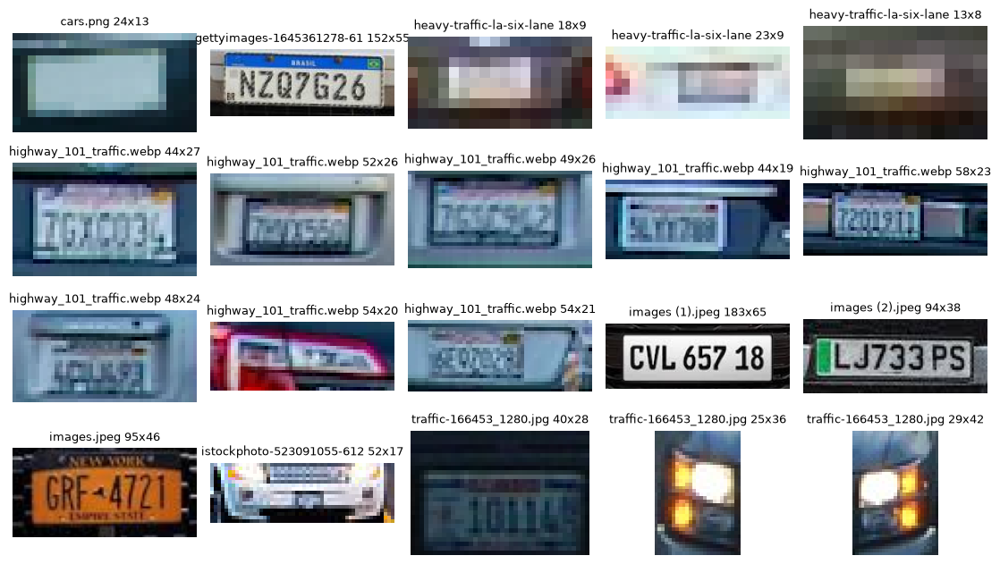

In [7]:
def recortar_placa(imagen, box, padding=CROP_PADDING):
    x0, y0, x1, y1 = box
    pad_x = (x1 - x0) * padding[0]
    pad_y = (y1 - y0) * padding[1]
    x0 = max(0, int(x0 - pad_x))
    y0 = max(0, int(y0 - pad_y))
    x1 = min(imagen.width, int(math.ceil(x1 + pad_x)))
    y1 = min(imagen.height, int(math.ceil(y1 + pad_y)))
    return imagen.crop((x0, y0, x1, y1))


for imagen, placas in zip(imagenes, detecciones):
    for placa in placas:
        placa["crop"] = recortar_placa(imagen, placa["box"])

recortes = [(ruta, placa) for ruta, placas in zip(rutas, detecciones) for placa in placas]
print("Placas recortadas:", len(recortes))
mostrar_galeria(
    [placa["crop"] for _, placa in recortes],
    [f"{ruta.name[:25]} {placa['crop'].width}x{placa['crop'].height}" for ruta, placa in recortes],
    columnas=5, alto=1.6,
)

## 5. Normalización y resize para el OCR

TrOCR usa su propio preprocesado, también guardado con el modelo: resize a 384×384, reescalado a 0–1 y normalización
con media y desviación 0.5 (valores en −1…1).

El checkpoint de TrOCR se guardó con Transformers 4.44. Al cargarlo con Transformers 5, la tabla de posiciones
sinusoidales del decodificador queda sin datos (en el dispositivo `meta`) y `generate` falla. Además, esa tabla no es un
búfer del modelo, así que `.to(device)` no la mueve a la GPU. Por eso se recalcula después de cargar, directamente en
`device`. El aviso `UNEXPECTED` sobre `_float_tensor` es un búfer antiguo sin uso y se puede ignorar.

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: /home/mambauser/workspace/outputs/final
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions._float_tensor | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tamaño: SizeDict(height=384, width=384, longest_edge=None, shortest_edge=None, max_height=None, max_width=None, min_pixels=None, max_pixels=None)
Media: (0.5, 0.5, 0.5)
Desviación: (0.5, 0.5, 0.5)
Generación: {'max_length': 64, 'early_stopping': True, 'num_beams': 4, 'use_cache': False, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'pad_token_id': 1, 'bos_token_id': 0, 'eos_token_id': 2, 'decoder_start_token_id': 0, 'transformers_version': '5.17.0'}
Placas con al menos 60 px de ancho: 4 de 20
pixel_values: (4, 3, 384, 384)


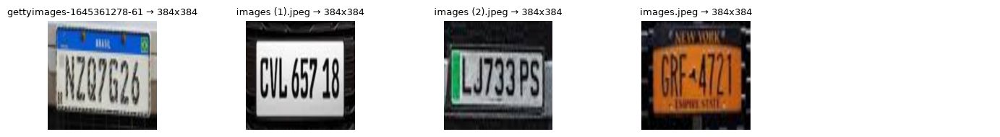

In [8]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

ocr_processor = TrOCRProcessor.from_pretrained(OCR_DIR)
ocr_model = VisionEncoderDecoderModel.from_pretrained(OCR_DIR).to(device)
ocr_model.eval()
posiciones = ocr_model.decoder.model.decoder.embed_positions
posiciones.weights = posiciones.get_embedding(
    ocr_model.config.decoder.max_position_embeddings + posiciones.padding_idx + 1,
    posiciones.embedding_dim,
    posiciones.padding_idx,
).to(device)

print("Tamaño:", ocr_processor.image_processor.size)
print("Media:", ocr_processor.image_processor.image_mean)
print("Desviación:", ocr_processor.image_processor.image_std)
print("Generación:", ocr_model.generation_config.to_diff_dict())

legibles = [(ruta, placa) for ruta, placa in recortes if placa["crop"].width >= MIN_OCR_WIDTH]
print(f"Placas con al menos {MIN_OCR_WIDTH} px de ancho: {len(legibles)} de {len(recortes)}")
if legibles:
    ocr_pixel_values = ocr_processor(images=[placa["crop"] for _, placa in legibles], return_tensors="pt").pixel_values
    print("pixel_values:", tuple(ocr_pixel_values.shape))
    mostrar_galeria(
        [desnormalizar(t, ocr_processor.image_processor.image_mean, ocr_processor.image_processor.image_std)
         for t in ocr_pixel_values],
        [f"{ruta.name[:25]} → 384x384" for ruta, _ in legibles],
        columnas=5, alto=2,
    )

## 6. OCR de las placas

Se generan los textos por lotes con la configuración de generación guardada (beam search de 4, máximo 64 tokens),
solo para las placas de al menos `MIN_OCR_WIDTH` píxeles de ancho. `texto` es la salida del modelo; `texto_limpio` la pasa a mayúsculas y deja solo letras, números y guiones, que es lo
esperable en una placa.

In [9]:
import re


@torch.no_grad()
def leer_texto(recortes_placa):
    textos = []
    if not recortes_placa:
        return textos
    for inicio in range(0, len(recortes_placa), BATCH_SIZE):
        lote = recortes_placa[inicio:inicio + BATCH_SIZE]
        pixel_values = ocr_processor(images=lote, return_tensors="pt").pixel_values.to(device)
        generated_ids = ocr_model.generate(pixel_values)
        textos.extend(ocr_processor.batch_decode(generated_ids, skip_special_tokens=True))
    return textos


def limpiar_texto(texto):
    return re.sub(r"[^A-Z0-9-]", "", texto.upper())


def aplicar_ocr(placas):
    for placa in placas:
        placa["leida"] = placa["crop"].width >= MIN_OCR_WIDTH
        placa["texto"] = placa["texto_limpio"] = ""
    legibles = [placa for placa in placas if placa["leida"]]
    for placa, texto in zip(legibles, leer_texto([placa["crop"] for placa in legibles])):
        placa["texto"] = texto.strip()
        placa["texto_limpio"] = limpiar_texto(texto)


aplicar_ocr([placa for _, placa in recortes])

import pandas as pd

tabla = pd.DataFrame([
    {
        "imagen": ruta.name,
        "confianza": round(placa["score"], 3),
        "caja": [round(v) for v in placa["box"]],
        "recorte": f"{placa['crop'].width}x{placa['crop'].height}",
        "leida": placa["leida"],
        "texto": placa["texto"],
        "texto_limpio": placa["texto_limpio"],
    }
    for ruta, placa in recortes
])
tabla

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


,imagen,confianza,caja,recorte,leida,texto,texto_limpio
0,cars.png,0.605,"[140, 313, 160, 322]",24x13,False,,
1,gettyimages-1645361278-612x612.jpg,0.895,"[230, 184, 360, 225]",152x55,True,ENZ07626,ENZ07626
2,heavy-traffic-la-six-lanes-footage-000759983_i...,0.683,"[108, 184, 122, 190]",18x9,False,,
3,heavy-traffic-la-six-lanes-footage-000759983_i...,0.489,"[169, 212, 188, 217]",23x9,False,,
4,heavy-traffic-la-six-lanes-footage-000759983_i...,0.478,"[41, 170, 51, 175]",13x8,False,,
5,highway_101_traffic.webp,0.673,"[579, 735, 616, 755]",44x27,False,,
6,highway_101_traffic.webp,0.636,"[141, 583, 185, 602]",52x26,False,,
7,highway_101_traffic.webp,0.603,"[159, 737, 200, 757]",49x26,False,,
8,highway_101_traffic.webp,0.486,"[344, 430, 381, 445]",44x19,False,,
9,highway_101_traffic.webp,0.483,"[1110, 607, 1159, 624]",58x23,False,,


## 7. Imagen de salida

Se dibuja cada placa sobre la imagen original con su texto y confianza (solo la confianza si es demasiado pequeña
para leerla), y se guarda en `RESULTS_DIR` junto con un CSV
de todas las lecturas.

Guardado en /home/mambauser/workspace/outputs/pipeline


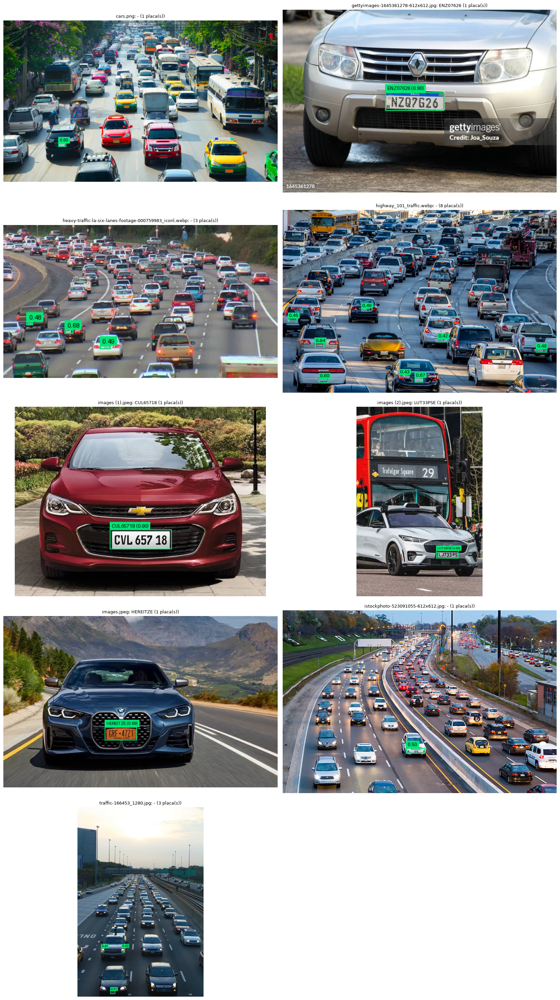

In [10]:
from PIL import ImageDraw, ImageFont

COLOR_CAJA = (0, 230, 118)
COLOR_TEXTO = (0, 0, 0)


def dibujar_resultado(imagen, placas):
    salida = imagen.copy()
    draw = ImageDraw.Draw(salida)
    grosor = max(2, round(min(salida.size) / 250))
    fuente = ImageFont.load_default(size=max(11, round(min(salida.size) / 40)))
    for placa in placas:
        x0, y0, x1, y1 = placa["box"]
        draw.rectangle((x0, y0, x1, y1), outline=COLOR_CAJA, width=grosor)
        etiqueta = f"{placa['texto_limpio'] or '?'} ({placa['score']:.2f})" if placa["leida"] else f"{placa['score']:.2f}"
        izq, arriba, der, abajo = draw.textbbox((0, 0), etiqueta, font=fuente)
        ancho, alto = der - izq, abajo - arriba
        margen = grosor + 2
        # La etiqueta va encima de la caja; si no cabe, debajo.
        ty = y0 - alto - 2 * margen if y0 - alto - 2 * margen >= 0 else y1
        tx = min(max(0, x0), salida.width - ancho - 2 * margen)
        draw.rectangle((tx, ty, tx + ancho + 2 * margen, ty + alto + 2 * margen), fill=COLOR_CAJA)
        draw.text((tx + margen - izq, ty + margen - arriba), etiqueta, fill=COLOR_TEXTO, font=fuente)
    return salida


salidas = [dibujar_resultado(imagen, placas) for imagen, placas in zip(imagenes, detecciones)]
for ruta, salida in zip(rutas, salidas):
    salida.save(RESULTS_DIR / f"{ruta.stem}_placas.jpg", quality=95)
tabla.to_csv(RESULTS_DIR / "lecturas.csv", index=False)
print("Guardado en", RESULTS_DIR)

mostrar_galeria(
    salidas,
    [f"{ruta.name}: {', '.join(p['texto_limpio'] or '?' for p in placas if p['leida']) or '-'} "
     f"({len(placas)} placa(s))"
     for ruta, placas in zip(rutas, detecciones)],
    columnas=2, alto=6,
)

## Pipeline completo en una función

`leer_placas` encadena todos los pasos anteriores para una imagen (ruta o `PIL.Image`) y devuelve las placas detectadas
con su texto y la imagen anotada. Sirve para probar imágenes nuevas.

'ENZ07626' (OCR: 'ENZ07626'), confianza 0.90


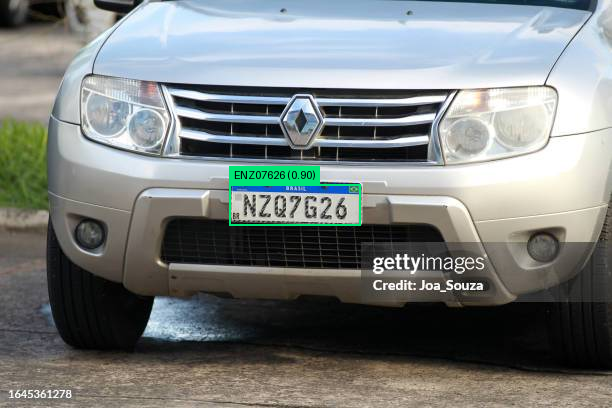

In [11]:
def leer_placas(imagen, threshold=DET_THRESHOLD):
    if not isinstance(imagen, Image.Image):
        imagen = cargar_imagen(imagen)
    placas = detectar_placas([imagen], threshold=threshold)[0]
    for placa in placas:
        placa["crop"] = recortar_placa(imagen, placa["box"])
    aplicar_ocr(placas)
    return placas, dibujar_resultado(imagen, placas)


# Ejemplo con la primera imagen que tenga alguna placa legible.
ejemplo = next((r for r, placas in zip(rutas, detecciones) if any(p["leida"] for p in placas)), rutas[0])
placas, anotada = leer_placas(ejemplo)
for placa in placas:
    lectura = f"{placa['texto_limpio']!r} (OCR: {placa['texto']!r})" if placa["leida"] else "demasiado pequeña"
    print(f"{lectura}, confianza {placa['score']:.2f}")
anotada